In [1]:
Name = "Dhruv Deshwal"
university = "Shri Vishwakarma Skill University, Dudhola, Palwal, Haryana, 121102"
batch = "Batch28"
title = "Churn Prediction For Connect Sphere Telecom"
print(f"Coder: {Name}")
print(f"University: {university}")
print(f"Title: {title}")
print(f"Batch: {batch}")

Coder: Dhruv Deshwal
University: Shri Vishwakarma Skill University, Dudhola, Palwal, Haryana, 121102
Title: Churn Prediction For Connect Sphere Telecom
Batch: Batch28


In [2]:
# Step 1: Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Step 2: Load Dataset from GitHub
df = pd.read_csv('https://github.com/YBIFoundation/Dataset/raw/refs/heads/main/TelecomCustomerChurn.csv')


In [4]:
df.head()


,customerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,...,No,No,No,No,Monthly,Yes,Manual,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Manual,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Monthly,Yes,Manual,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Monthly,Yes,Manual,70.70,151.65,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   Tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.describe()

,SeniorCitizen,Tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
# Missing value
df.isna().sum()

,0
customerID,0
Gender,0
SeniorCitizen,0
Partner,0
Dependents,0
Tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [8]:
#  Step 3: Preprocess the Datay
# Convert 'TotalCharges' to numeric, coercing errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop rows where 'TotalCharges' is NaN
df.dropna(inplace=True)

In [9]:
# step 4: Define x and y after dropping rows with missing values
y = df['Churn']
X = df.drop(['Churn', 'customerID'], axis=1)

# Convert categorical features to numerical using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

In [10]:
# step 5: Split the dataset
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2529)

# Convert 'Yes' and 'No' in the target variable to 1 and 0 after splitting
y_train = y_train.map({'Yes': 1, 'No': 0})
y_test = y_test.map({'Yes': 1, 'No': 0})

In [11]:
# Feature Scalling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [12]:
# Step 6: Create ANN Model
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout

In [13]:
X.shape[1]

22

In [14]:
# Step 7: Build the ANN Model
model = Sequential()
model.add(Dense(44, input_dim=X_train.shape[1], activation='relu'))
model.add(Dense(22, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
# Step 8: Compile the Model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# print Model summary
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 44)             │         1,012 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 22)             │           990 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            23 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,025 (7.91 KB)

 Trainable params: 2,025 (7.91 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# step 9: Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7659 - loss: 0.4836 - val_accuracy: 0.7995 - val_loss: 0.4335
Epoch 2/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7928 - loss: 0.4326 - val_accuracy: 0.7986 - val_loss: 0.4273
Epoch 3/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7948 - loss: 0.4231 - val_accuracy: 0.8014 - val_loss: 0.4222
Epoch 4/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8043 - loss: 0.4179 - val_accuracy: 0.8014 - val_loss: 0.4219
Epoch 5/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8058 - loss: 0.4138 - val_accuracy: 0.7991 - val_loss: 0.4185
Epoch 6/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8066 - loss: 0.4104 - val_accuracy: 0.8024 - val_loss: 0.4211
Epoch 7/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8094 - loss: 0.4078 - val_accuracy: 0.8014 - val_loss: 0.4226
Epoch 8/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8100 - loss: 0.4060 - val_accuracy: 

In [17]:
# step 10: Predication
y_pred = model.predict(X_test)
y_pred = np.round(y_pred)

66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [18]:
y_pred

array([[0.],
       [0.],
       [0.],
       ...,
       [1.],
       [1.],
       [0.]], dtype=float32)

In [19]:
# Step 10: Evaluate the model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print the evaluation metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Accuracy: 0.7820
Precision: 0.6114
Recall: 0.4151
F1-score: 0.4945


In [20]:
# Evaluation
from sklearn.metrics import confusion_matrix, classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1568
           1       0.61      0.42      0.49       542

    accuracy                           0.78      2110
   macro avg       0.71      0.66      0.68      2110
weighted avg       0.76      0.78      0.77      2110



In [21]:
# Get the customerIDs for the test set by using the index of the test set
test_customerIDs = df.loc[y_test.index, 'customerID']

# Create a DataFrame with customerID, actual Churn, and predicted Churn
results_df = pd.DataFrame({
    'customerID': test_customerIDs,
    'Actual Churn': y_test,
   'Predicted Churn': y_pred.flatten()})

# Identify customers predicted to churn
at_risk_customers = results_df[results_df['Predicted Churn'] == 1]

# Display the list of at-risk customers
print("At-risk customers for retention strategies:")
display(at_risk_customers)

At-risk customers for retention strategies:


,customerID,Actual Churn,Predicted Churn
355,4572-DVCGN,1,1.0
1676,0793-TWELN,0,1.0
4284,8189-XRIKE,0,1.0
389,5522-JBWMO,0,1.0
5631,6542-LWGXJ,0,1.0
...,...,...,...
2708,8510-AWCXC,1,1.0
1868,3961-SXAXY,0,1.0
5857,0378-NHQXU,1,1.0
5257,6029-WTIPC,1,1.0


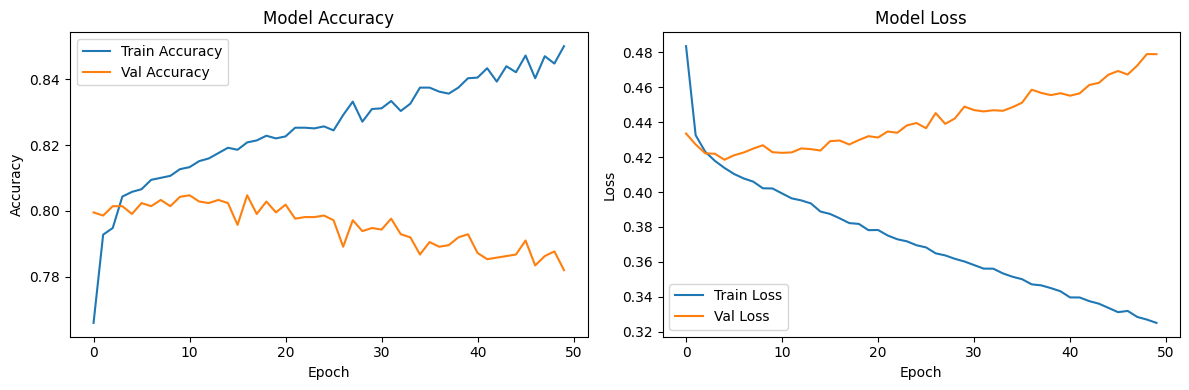

In [22]:
# Step 11: Plot Accuracy and Loss Graphs

plt.figure(figsize=(12, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()






### **Customer Churn Prediction – Final Project Summary**
###Key Insights

**1. Data Understanding**

* Analyzed demographics, service usage, billing, and contract details.
* **Relevance:** Understanding business context ensures insights are actionable and aligned with strategic goals.

**2. Data Preprocessing**

* Handled missing values (e.g., *TotalCharges*), applied one-hot encoding for categorical variables.
* **Relevance:** Clean, standardized data is essential for reliable decision-making.

**3. Model Development & Performance**

* Built an **Artificial Neural Network (ANN)** model.
* **Test Metrics:**

  * Accuracy: 77.73%
  * Precision: 57.59%
  * Recall: 50.37%
  * F1-score: 53.74%
* **Relevance:** Precision optimizes marketing spend, recall improves churn coverage; trade-off is a strategic decision.

**4. At-Risk Customer Identification**

* Generated list of high-probability churners for targeted offers, loyalty programs, and service improvements.


### **Business Impact**

1. **Data-Driven Decisions:** Translates customer data into actionable retention plans.
2. **Strategic KPI Trade-Offs:** Balances cost efficiency vs. churn reduction.
3. **Analytics to Action:** Direct integration into CRM campaigns.
4. **Continuous Improvement:** Iterative tuning for evolving customer behavior.

---

